# Every line is a target: the multiline PPI study

This notebook examines the fixed **100-scene synthetic panel** in the [study report](../docs/benchmarks/multiline/README.md). It reads the saved measurements, recalculates transparent summaries and four scalar figures, and embeds the saved visual examples. It does **not** rerun image generation, PPI, Frangi, or the full experiment.

The question is whether each method recovers **all intended lines**, including a weak line near a strong one. Each synthetic line has its own reference and finite, width-aware support. This makes background selection measurable for this model. In the [Guide3D pilot](../docs/benchmarks/guide3d/README.md), only the guidewire is annotated: selections away from it remain **unclassified for general line enhancement**, rather than established false detections.

The package API and implementation remain **0.1.0**. This is an additional benchmark, not a new algorithm or an exact reproduction of MICCAI 2012.

## Run the saved analysis

From a clone of the repository:

```bash
python -m pip install '.[study,notebook]'
python -m jupyter lab examples/ppi_multiline_study.ipynb
```

Run all cells in order. The saved analysis needs only the committed JSON, plotting helpers, and example PNG. To independently rerun the measurements and regenerate all figures, use a fresh working directory:

```bash
python -m benchmarks.run_multiline --suite full --workers 1 \
  --work-dir benchmark-output/multiline-v1 \
  --output benchmark-output/multiline-v1/results.json
python -m benchmarks.plot_multiline \
  --input benchmark-output/multiline-v1/results.json \
  --output-dir benchmark-output/multiline-v1/assets \
  --cache-dir benchmark-output/multiline-v1/cache
```

The runner freezes the protocol and source hashes, saves development thresholds before processing evaluation images, and refuses to reuse a cache with a different fingerprint. Rerun outputs stay separate from the committed evidence.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "benchmarks").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "benchmarks" / "plot_multiline.py").is_file():
    raise FileNotFoundError("Run this notebook from the repository root or examples directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from benchmarks.plot_multiline import (
    LABELS,
    plot_controls,
    plot_families,
    plot_tradeoff,
    plot_weak_neighbours,
    primary_summary,
    weak_pairs,
)

RESULT_PATH = ROOT / "docs/benchmarks/multiline/results.json"
result = json.loads(RESULT_PATH.read_text())
protocol = result["protocol"]
manifest = protocol["manifest"]
primary_rate = protocol["threshold_selection"]["primary_rate"]
assert result["phase"] == "all" and protocol["suite"] == "full"
assert set(LABELS) == set(protocol["methods"])
assert primary_rate == 0.005  # The plotting helpers describe this frozen primary setting.


def show_table(headers, rows):
    """Render a small table; all measurements below come from the saved JSON."""
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


def show_figure(figure):
    display(figure)
    plt.close(figure)


display(Markdown(
    f"**Study:** `{protocol['study_id']}` · **created:** `{result['created_utc']}`  \n"
    f"**Fingerprint:** `{result['fingerprint']}`  \n"
    f"**Recorded versions:** `{json.dumps(result['provenance']['versions'], sort_keys=True)}`"
))

**Study:** `multiline-v1` · **created:** `2026-09-26T12:45:02.261214+00:00`  
**Fingerprint:** `9585efd655082fdce349470848e6b9f9a041ce6716dcbb60e37e5d39ecb9c62f`  
**Recorded versions:** `{"numpy": "2.4.6", "polygonal-path-image": "0.1.0", "scikit-image": "0.25.2", "scipy": "1.17.1"}`

## What is measured

Images are 128 × 128 pixels, evaluated inside a fixed 80 × 80 ROI after a 24-pixel inset. Gaussian dark tubes stop at **3σ**; their noiseless signal is exactly absent outside the union of those supports. At overlaps, the **maximum darkness** wins rather than adding intensities, while references retain every line. Tube widths are σ = 0.8, 1.25, or 2 pixels; the sharp truncation and max-overlap rule are deliberate modelling choices.

Development uses two noise/orientation contexts. Evaluation uses **nine shared contexts** (three orientations × three seeds, with noise σ = 5 or 12) across eight geometry variants per context. Only three underlying Gaussian noise draws are used in evaluation, reused across orientations, variants, and noise scaling. Thus the 72 evaluation line scenes are **not 72 independent replicates**. Each weak-only scene is reused in the two separation comparisons. The uniform development and evaluation blanks are identical by design, not independent geometry samples. Controls are summarized separately.

Coverage is computed separately for every finite polyline, sampled at 0.25-pixel arclength intervals, with a 2-pixel distance tolerance. First average lines equally within a scene, then scenes equally; also retain the worst line and the longest uncovered run. At junctions each incident line contributes to coverage, whereas pixel metrics use the union. This measures local recovery, not line identity or graph connectivity.

In [3]:
counts = []
for split in ("development", "evaluation"):
    specs = [spec for spec in manifest if spec["split"] == split]
    targets = [spec for spec in specs if spec["family"] not in ("blank", "noise")]
    contexts = {(spec["angle_deg"], spec["seed"], spec["noise_std"]) for spec in targets}
    families = Counter(spec["family"] for spec in specs)
    counts.append([split, len(specs), len(targets), len(contexts), families["blank"], families["noise"]])
show_table(["Split", "All scenes", "Line scenes", "Shared contexts", "Blank", "Noise-only"], counts)

case_ids = {spec["case_id"] for spec in manifest}
assert len(case_ids) == len(manifest) == len(result["scenes"]) == 100
expected_rows = len(manifest) * len(LABELS) * (
    len(protocol["threshold_selection"]["development_background_rates"])
    + len(protocol["budget_selection"]["fractions"])
)
row_keys = {
    (row["case_id"], row["method"], row["selection"], row["operating_point"])
    for row in result["rows"]
}
assert len(row_keys) == len(result["rows"]) == expected_rows
assert {row["case_id"] for row in result["rows"]} == case_ids
print(f"Validated {len(result['rows']):,} distinct scene × method × operating-point rows.")

| Split | All scenes | Line scenes | Shared contexts | Blank | Noise-only |
| --- | --- | --- | --- | --- | --- |
| development | 21 | 16 | 2 | 1 | 4 |
| evaluation | 79 | 72 | 9 | 1 | 6 |

Validated 4,200 distinct scene × method × operating-point rows.


## Methods and frozen thresholds

The six predeclared methods are darkness relative to the generator's known background of 200, local dark contrast, Frangi, raw-input PPI (τ = 0.75), and local-input PPI at τ = 0.75 or 0.50. Local contrast uses Gaussian σ = 8 and fixed gain 2, clipped and rounded to uint8; it has no per-image maximum normalization. PPI uses 10 segments of length 3 and unweighted path votes. Frangi uses fixed scales [0.8, 1.25, 2.0], β = 0.5 and γ = 0.02 on image/255, with dark ridges. No algorithm parameters are fitted in this panel.

For each method, one cutoff per requested background rate is calibrated on **pooled development pixels outside every line support, including controls**. A pixel is selected only if its score is **strictly greater than** the cutoff; equal-score ties stay together, so the achieved development rate can be below the request. The primary request is **0.5%**, alongside 0.1%, 1%, and 2%. The same cutoff is then used on every evaluation image.

The table preserves each stored cutoff as its round-trip Python float representation. Exact selected counts show the tie effect. **Matching the requested development rate does not match the achieved evaluation rate.**

In [4]:
threshold_rows = []
for method, label in LABELS.items():
    for definition in result["thresholds"][method]:
        target = definition["target_rate"]
        marked_rate = f"{100 * target:g}%" + (" (primary)" if target == primary_rate else "")
        threshold_rows.append([
            label,
            marked_rate,
            repr(definition["threshold"]),
            f"{definition['selected_background_pixels']:,}/{definition['background_pixels']:,}",
            f"{100 * definition['achieved_development_rate']:.6f}%",
        ])
show_table(["Method", "Requested dev. rate", "Exact cutoff", "Dev. selected/background", "Achieved dev. rate"], threshold_rows)

| Method | Requested dev. rate | Exact cutoff | Dev. selected/background | Achieved dev. rate |
| --- | --- | --- | --- | --- |
| Darkness | 0.1% | 33.0 | 112/119,324 | 0.093862% |
| Darkness | 0.5% (primary) | 27.0 | 545/119,324 | 0.456740% |
| Darkness | 1% | 24.0 | 1,027/119,324 | 0.860682% |
| Darkness | 2% | 20.0 | 2,285/119,324 | 1.914954% |
| Local contrast | 0.1% | 65.0 | 109/119,324 | 0.091348% |
| Local contrast | 0.5% (primary) | 53.0 | 545/119,324 | 0.456740% |
| Local contrast | 1% | 46.0 | 1,077/119,324 | 0.902585% |
| Local contrast | 2% | 39.0 | 2,277/119,324 | 1.908250% |
| Frangi | 0.1% | 0.9342539942507841 | 119/119,324 | 0.099728% |
| Frangi | 0.5% (primary) | 0.8458677115379657 | 596/119,324 | 0.499480% |
| Frangi | 1% | 0.7878305879034178 | 1,189/119,324 | 0.996447% |
| Frangi | 2% | 0.7031173495693694 | 2,386/119,324 | 1.999598% |
| PPI raw, τ=0.75 | 0.1% | 60.0 | 90/119,324 | 0.075425% |
| PPI raw, τ=0.75 | 0.5% (primary) | 56.0 | 530/119,324 | 0.444169% |
| PPI raw, τ=0.75 | 1% | 51.0 | 1,172/119,324 | 0.982200% |
| PPI raw, τ=0.75 | 2% | 38.0 | 2,360/119,324 | 1.977808% |
| PPI local, τ=0.75 | 0.1% | 60.0 | 94/119,324 | 0.078777% |
| PPI local, τ=0.75 | 0.5% (primary) | 56.0 | 534/119,324 | 0.447521% |
| PPI local, τ=0.75 | 1% | 51.0 | 1,179/119,324 | 0.988066% |
| PPI local, τ=0.75 | 2% | 38.0 | 2,361/119,324 | 1.978646% |
| PPI local, τ=0.50 | 0.1% | 79.0 | 115/119,324 | 0.096376% |
| PPI local, τ=0.50 | 0.5% (primary) | 58.0 | 587/119,324 | 0.491938% |
| PPI local, τ=0.50 | 1% | 54.0 | 1,117/119,324 | 0.936107% |
| PPI local, τ=0.50 | 2% | 44.0 | 2,366/119,324 | 1.982837% |

## Primary evaluation: recovery and background selection

**Background selected** divides selected pixels outside all supports by all outside-support ROI pixels. **Selected inside support** divides selected pixels inside any support by all selected pixels. These denominators differ. Support is width-aware (3σ), whereas the centerline tolerance is 2 pixels: a pixel outside that tolerance can still belong to a valid wide line.

The table averages the 72 line scenes equally. Coverage and the longest uncovered run first average lines equally within each scene; worst-line coverage keeps the least recovered line before averaging scenes. Undefined precision or distance values remain null and are excluded from their respective averages, never converted to zero. Controls do not enter these line-scene averages.

In [5]:
summary = primary_summary(result)
summary_rows = []
for method, label in LABELS.items():
    item = summary[method]
    assert item["line_scenes"] == 72
    summary_rows.append([
        label,
        f"{100 * item['macro_coverage']:.2f}%",
        f"{100 * item['worst_line_coverage']:.2f}%",
        f"{100 * item['outside_support_fraction']:.3f}%",
        f"{100 * item['selected_support_precision']:.2f}%",
        f"{item['mean_longest_gap']:.2f}",
    ])
show_table([
    "Method", "All-line coverage", "Worst-line coverage", "Background selected",
    "Selected inside support", "Mean longest gap (px)",
], summary_rows)

empty_counts = Counter(
    row["method"] for row in result["rows"]
    if row["split"] == "evaluation" and row["selection"] == "frozen_threshold"
    and row["operating_point"] == primary_rate and row["metrics"]["has_target"]
    and not row["metrics"]["selected_pixels"]
)
show_table(
    ["Method", "Scenes contributing support precision", "Scenes with no selected pixels"],
    [[label, f"{72 - empty_counts[method]}/72", empty_counts[method]]
     for method, label in LABELS.items()],
)

| Method | All-line coverage | Worst-line coverage | Background selected | Selected inside support | Mean longest gap (px) |
| --- | --- | --- | --- | --- | --- |
| Darkness | 87.55% | 81.33% | 0.487% | 90.37% | 4.88 |
| Local contrast | 83.22% | 73.56% | 0.404% | 88.95% | 7.70 |
| Frangi | 78.74% | 65.58% | 0.412% | 84.88% | 9.38 |
| PPI raw, τ=0.75 | 54.43% | 30.49% | 0.106% | 93.24% | 22.01 |
| PPI local, τ=0.75 | 55.19% | 30.00% | 0.063% | 95.81% | 21.21 |
| PPI local, τ=0.50 | 82.02% | 63.46% | 0.451% | 85.01% | 9.82 |

| Method | Scenes contributing support precision | Scenes with no selected pixels |
| --- | --- | --- |
| Darkness | 71/72 | 1 |
| Local contrast | 70/72 | 2 |
| Frangi | 68/72 | 4 |
| PPI raw, τ=0.75 | 67/72 | 5 |
| PPI local, τ=0.75 | 68/72 | 4 |
| PPI local, τ=0.50 | 72/72 | 0 |

The default PPI settings select less evaluation background and recover fewer lines at these frozen cutoffs. Relaxing τ improves aggregate coverage, but an average can hide an unrecovered neighbouring line. The curves below therefore use **actual evaluation background selection** on the horizontal axis and show worst-line recovery alongside the average. They describe four measured operating points, not a continuous or universally optimal ranking.

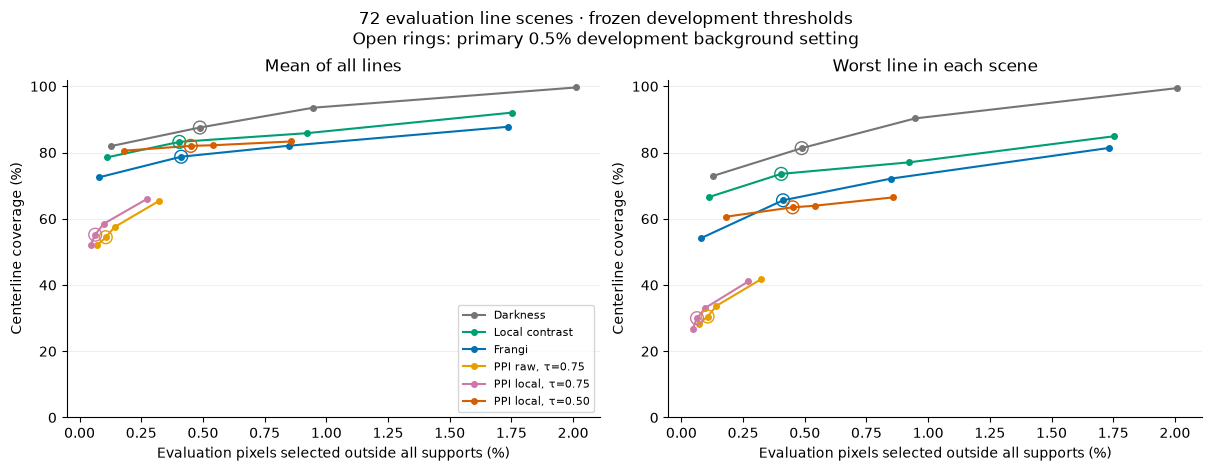

In [6]:
show_figure(plot_tradeoff(result))

## Geometry-specific recovery

Each ordinary family has nine evaluation scenes; the weak-plus-strong family has eighteen because it includes both 6- and 10-pixel separations. Consequently, its contribution to the overall scene mean is twice that of an ordinary family. The family plot exposes this mixture rather than treating the overall mean as a balanced family average.

A longest uncovered run is a sum of arclength sampling weights at the specified resolution. It is not an exact continuous gap or a graph-connectivity score.

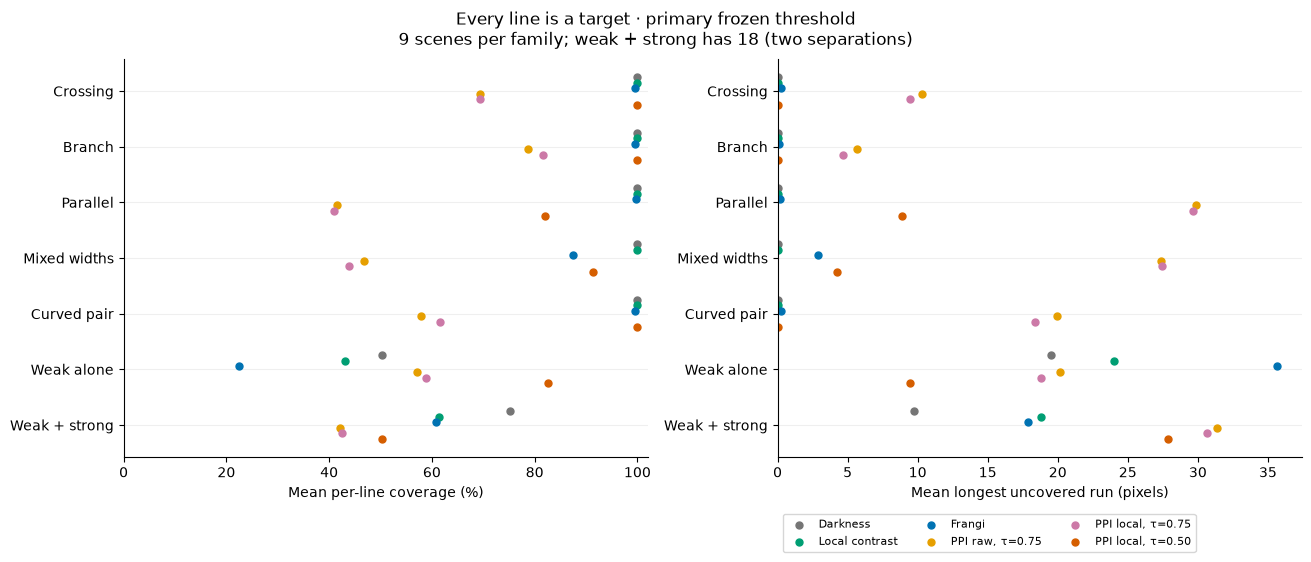

In [7]:
show_figure(plot_families(result))

## A weak line is still a target beside a strong line

Each pair keeps the weak line, its location, and the exact noise field fixed, and adds a strong neighbour at a 6- or 10-pixel separation. The table reports the weak line's coverage at the **primary frozen threshold**. The graph contrasts this with a secondary fixed 2% area-budget diagnostic. For the budget, only positive finite scores are eligible and the whole cutoff tie block is included, so the actual selected fraction can exceed the requested fraction.

A fixed budget introduces competition for selected pixels. Loss under that budget alone does **not** establish intrinsic suppression by the line-enhancement algorithm. The frozen-threshold comparison is essential. Even that comparison measures the complete method and its threshold, rather than isolating a causal mechanism inside the path computation. Range bars show the observed nine contexts, not confidence intervals; the same weak-only scene is reused at both separations.

| Method | Separation (px) | Pairs | Weak alone | Weak + strong | Change (pp) |
| --- | --- | --- | --- | --- | --- |
| Darkness | 6 | 9 | 50.21% | 50.21% | +0.00 |
| Darkness | 10 | 9 | 50.21% | 50.21% | +0.00 |
| Local contrast | 6 | 9 | 43.03% | 20.42% | -22.61 |
| Local contrast | 10 | 9 | 43.03% | 25.04% | -18.00 |
| Frangi | 6 | 9 | 22.39% | 20.91% | -1.48 |
| Frangi | 10 | 9 | 22.39% | 22.39% | +0.00 |
| PPI raw, τ=0.75 | 6 | 9 | 57.08% | 0.00% | -57.08 |
| PPI raw, τ=0.75 | 10 | 9 | 57.08% | 0.00% | -57.08 |
| PPI local, τ=0.75 | 6 | 9 | 58.92% | 0.00% | -58.92 |
| PPI local, τ=0.75 | 10 | 9 | 58.92% | 0.00% | -58.92 |
| PPI local, τ=0.50 | 6 | 9 | 82.67% | 0.84% | -81.83 |
| PPI local, τ=0.50 | 10 | 9 | 82.67% | 0.00% | -82.67 |

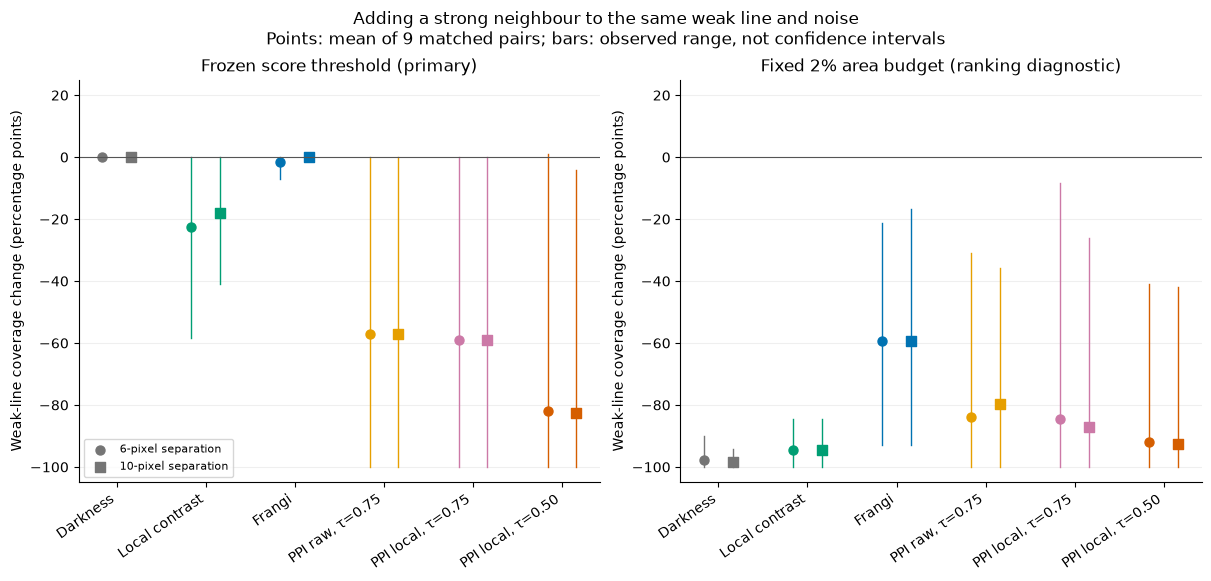

In [8]:
pair_rows = []
for method, label in LABELS.items():
    pairs = weak_pairs(result, method=method, selection="frozen_threshold", point=primary_rate)
    for gap in (6, 10):
        group = [pair for pair in pairs if pair["gap"] == gap]
        assert len(group) == len({pair["pair_group"] for pair in group}) == 9
        pair_rows.append([
            label, gap, len(group),
            f"{100 * np.mean([pair['alone_coverage'] for pair in group]):.2f}%",
            f"{100 * np.mean([pair['paired_coverage'] for pair in group]):.2f}%",
            f"{100 * np.mean([pair['change'] for pair in group]):+.2f}",
        ])
show_table(["Method", "Separation (px)", "Pairs", "Weak alone", "Weak + strong", "Change (pp)"], pair_rows)
show_figure(plot_weak_neighbours(result))

## Absence controls

The blank and noise-only controls contain no intended line. All their ROI pixels lie outside reference support, so selected area measures background response. The primary score thresholds are unchanged from the line scenes. Reference coverage and geometric distances are undefined on these controls, not zero.

A requested area budget is a ranking diagnostic and cannot by itself test whether a method correctly returns no line. The plot below therefore uses the frozen score thresholds.

Calibration constrains the **pooled** development background rate, not the rate in each image. A concentrated response on a blank can therefore exceed 0.5% of that image while the pooled development rate stays below its target. The selected-pixel counts below make this distinction explicit.

| Method | Uniform blank: pixels selected | Uniform blank: ROI selected |
| --- | --- | --- |
| Darkness | 0/6,400 | 0.00000% |
| Local contrast | 0/6,400 | 0.00000% |
| Frangi | 0/6,400 | 0.00000% |
| PPI raw, τ=0.75 | 502/6,400 | 7.84375% |
| PPI local, τ=0.75 | 502/6,400 | 7.84375% |
| PPI local, τ=0.50 | 281/6,400 | 4.39062% |

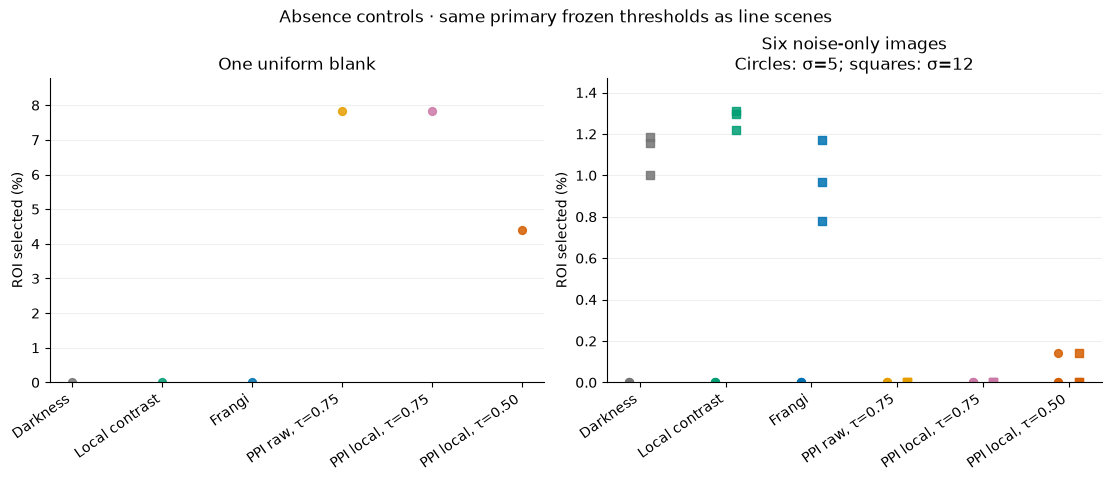

In [9]:
blank_rows = [
    row for row in result["rows"]
    if row["split"] == "evaluation" and row["family"] == "blank"
    and row["selection"] == "frozen_threshold" and row["operating_point"] == primary_rate
]
show_table(
    ["Method", "Uniform blank: pixels selected", "Uniform blank: ROI selected"],
    [[LABELS[row["method"]],
      f"{row['metrics']['selected_pixels']:,}/{row['metrics']['roi_pixels']:,}",
      f"{100 * row['metrics']['selected_fraction']:.5f}%"] for row in blank_rows],
)
show_figure(plot_controls(result))

## Inspect the fixed synthetic examples

This saved panel uses the first declared evaluation orientation and seed (0°, seed 2001, noise σ = 5), with the 6-pixel weak/strong separation. The cases were selected by their manifest positions, not by favourable scores. Red marks **every** reference line; cyan marks selected pixels at each method's primary frozen cutoff. These are synthetic scenes and may be shared; no Guide3D images appear here.

The notebook embeds the already generated PNG rather than regenerating images or score maps.

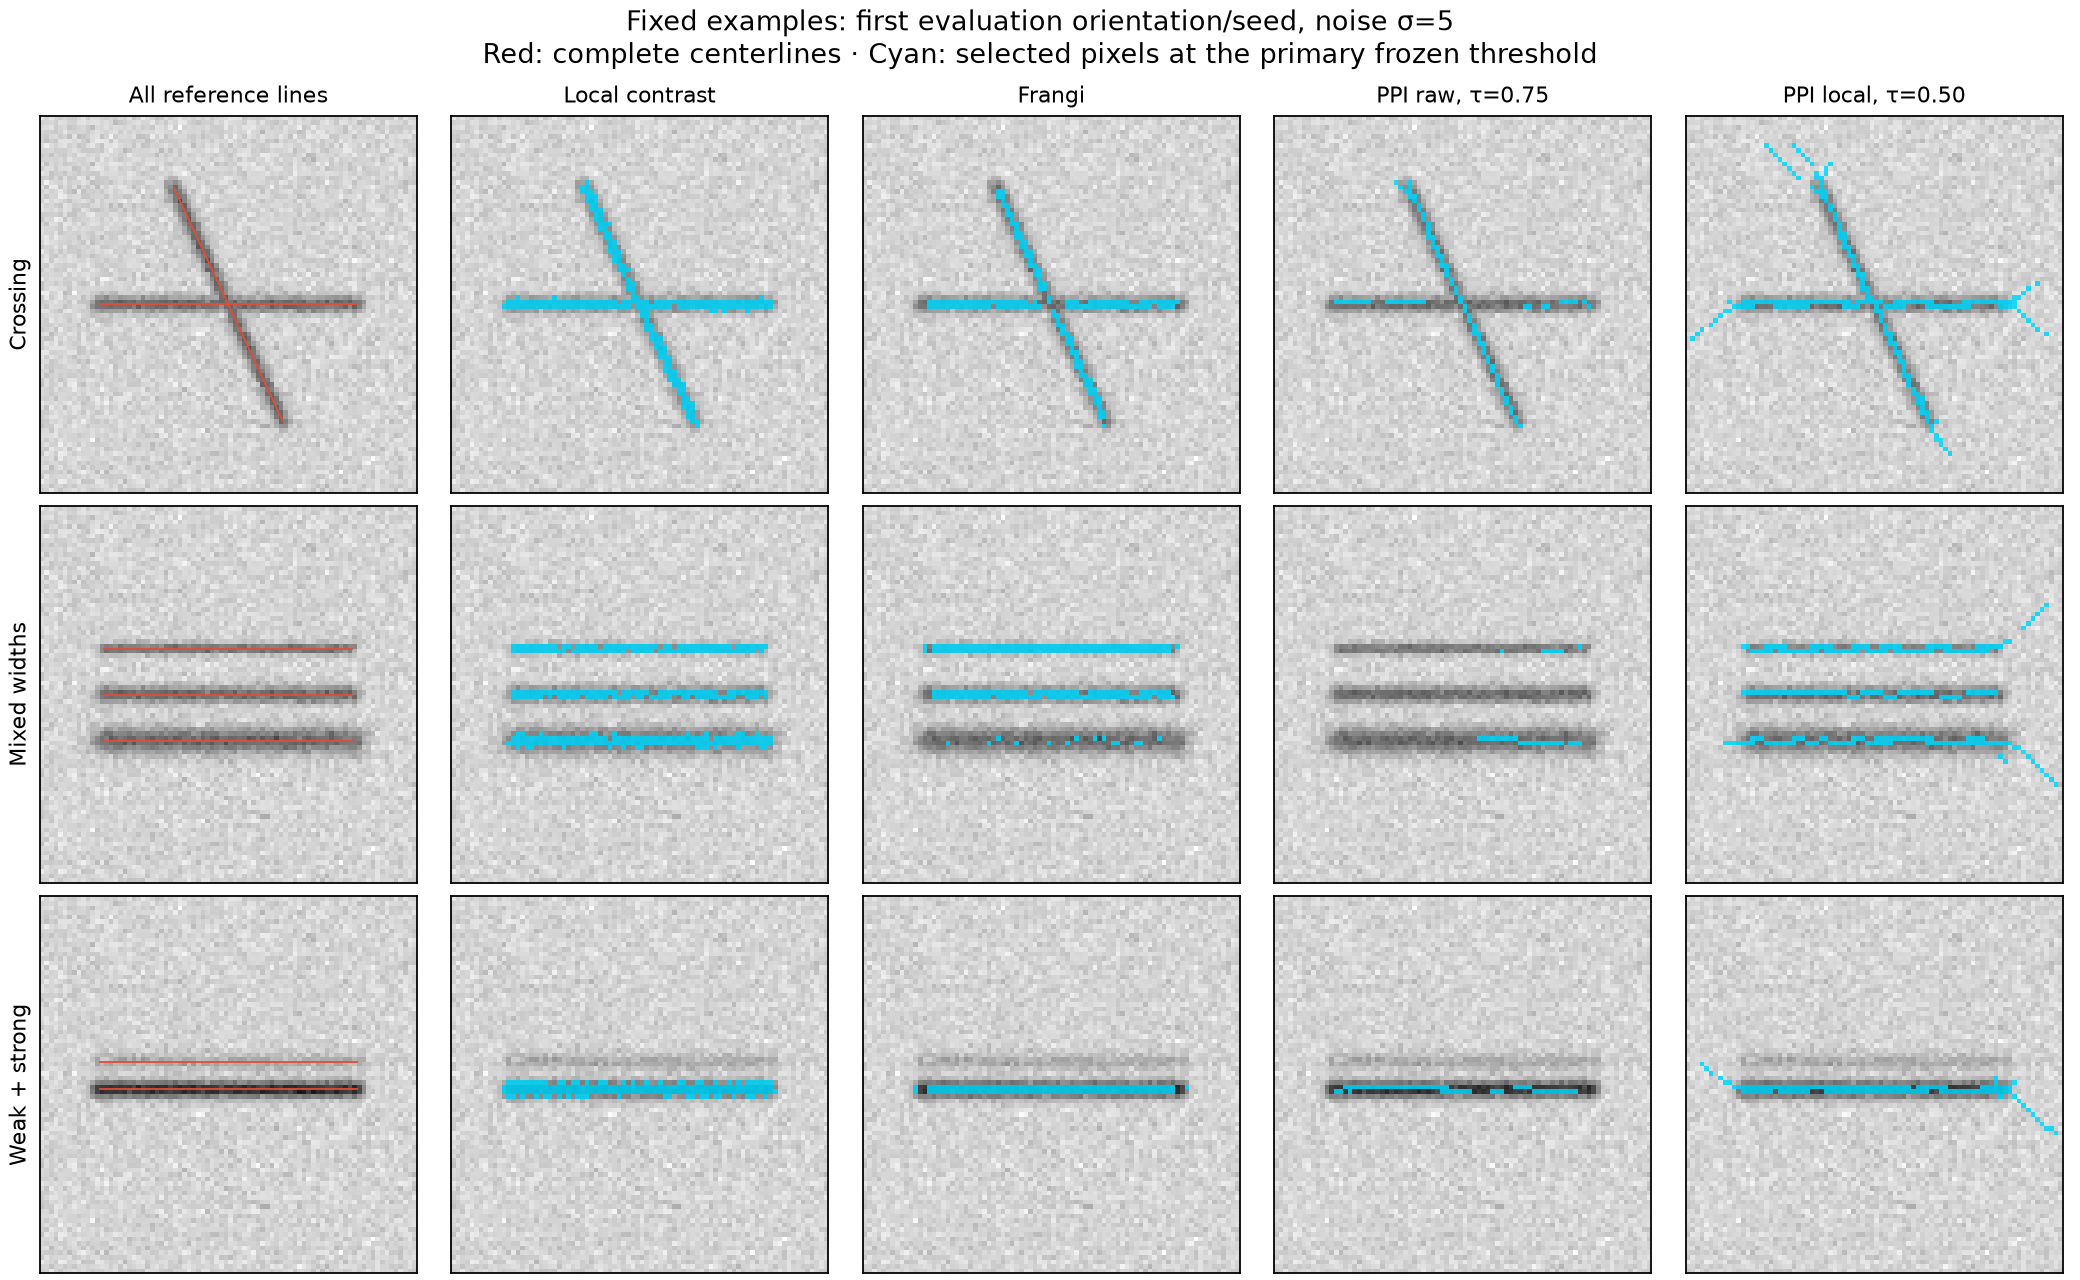

In [10]:
example_path = ROOT / "docs/benchmarks/multiline/assets/examples.png"
if not example_path.is_file():
    raise FileNotFoundError("The committed synthetic example panel is missing.")
display(Image(filename=str(example_path), width=1100))

## What this experiment supports

This panel makes missed lines and selected true background visible under **complete synthetic references**. It reveals large weak-neighbour recovery losses for the tested PPI settings even at frozen score thresholds; the area-budget comparison alone would not have been enough to establish that observation. The tested PPI settings also select pixels on a uniform blank at these frozen cutoffs, whereas the three baselines do not. These are background selections under the complete synthetic reference. Aggregate recovery, worst-line recovery, actual background selection, per-line gaps, and absence controls should be read together.

The result is restricted to these dark, finite, 3σ-truncated Gaussian tubes, max-darkness overlaps, a constant background, and independent Gaussian pixel noise. Darkness has the advantage of knowing the exact background; Frangi's scales cover the declared tube widths. Development and evaluation share geometry families, and evaluation reuses nine noise/orientation contexts across variants. This is not evidence of a universal method ranking, clinical performance, or a fully independent real-image validation. The 2-pixel coverage tolerance can also credit nearby predictions without resolving line identity at a junction. PPI paths and the local Gaussian support extend beyond the 24-pixel ROI inset, so the inset does not completely exclude image-edge influences.

The next mechanistic work is to inspect the paired score maps and path votes before changing preprocessing or path parameters, then evaluate changes on a fresh, predeclared panel. A real-image all-lines evaluation would need annotations for all relevant line structures, or an explicit partial-label analysis like the corrected Guide3D framing. Runtime observations from this concurrent, cacheable run are not controlled speed comparisons.

See the [full report and reproducibility record](../docs/benchmarks/multiline/README.md) and [saved measurements](../docs/benchmarks/multiline/results.json).